# Ocular Disease Recognition — Grouped Classification

Same EfficientNetB0 transfer learning pipeline as `02_model_training.ipynb`, reformulated as a
**4-group clinical taxonomy** instead of 8 individual diagnoses.

The grouping absorbs the statistically unreliable Hypertension class (103 training samples) into
the Vascular group and reduces the imbalance ratio from 3.55:1 to ~1.2:1 after augmentation.

| Group | Classes | Clinical rationale |
|---|---|---|
| Normal | N | Healthy retina |
| Vascular / Metabolic | D + H | Vascular damage from elevated glucose or blood pressure |
| Structural / Mechanical | G + C + M | Physical changes: optic disc, lens opacity, axial elongation |
| Degenerative / Other | A + O | Macular degeneration and heterogeneous conditions |

# Environment Setup (Google Colab)

Uncomment and run the block below **only** when running on Google Colab. For local execution, skip this cell entirely.

In [1]:
# ── Run this block ONLY when using Google Colab ────────────────────────
# 1. Upload train_data.h5 and test_data.h5 to Google Drive at:  My Drive/ocular/
# 2. For images choose Option A (Drive) or Option B (Kaggle API)
# 3. Uncomment the entire block and run before any other cell

# import os, shutil
# from google.colab import drive
# drive.mount('/content/drive')

# DRIVE_DIR = '/content/drive/MyDrive/ocular'

# os.makedirs('/content/Main', exist_ok=True)
# os.makedirs('/content/models', exist_ok=True)
# os.makedirs('/content/notebooks', exist_ok=True)

# shutil.copy(f'{DRIVE_DIR}/train_data.h5', '/content/Main/train_data.h5')
# shutil.copy(f'{DRIVE_DIR}/test_data.h5',  '/content/Main/test_data.h5')
# os.chdir('/content/notebooks')

# # Option A — images already uploaded to Drive:
# IMAGE_FOLDER_PATH = f'{DRIVE_DIR}/preprocessed_images'

# # Option B — download from Kaggle:
# shutil.copy(f'{DRIVE_DIR}/kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
# os.system('kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k -p /content/preprocessed_images --unzip')
# IMAGE_FOLDER_PATH = '/content/preprocessed_images'

# import tensorflow as tf
# print('GPU:', tf.config.list_physical_devices('GPU'))


# 1. Imports

In [ ]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, log_loss
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from utils.image_utils import load_images, augment_images

# 2. Data Loading

In [3]:
train_data_path = '../Main/train_data.h5'
test_data_path  = '../Main/test_data.h5'

train_data = pd.read_hdf(train_data_path)
test_data  = pd.read_hdf(test_data_path)
train_data.head()


,ID,Patient Age,Patient Sex,target,filename,diagnostic,binary_target
6306,4584,42,Male,1,4584_left.jpg,D,0
2244,3126,41,Male,0,3126_right.jpg,N,1
1716,2553,54,Female,0,2553_right.jpg,N,1
6368,4653,68,Male,1,4653_left.jpg,D,0
4970,2618,58,Male,0,2618_left.jpg,N,1


## 2.1 Feature / Target Split

In [4]:
X_train, y_train = train_data.drop(columns=['target']), train_data['target']
X_test,  y_test  = test_data.drop(columns=['target']),  test_data['target']
print('8-class distribution (train):')
print(y_train.value_counts().sort_index())


8-class distribution (train):
target
0    2298
1    1286
2     227
3     234
4     213
5     103
6     186
7     566
Name: count, dtype: int64


## 2.2 Clinical Group Mapping

The 8 individual diagnoses are merged into 4 clinically coherent groups based on shared
aetiology and visual presentation in fundus photography.

| Group | Label | Original classes | Rationale |
|---|---|---|---|
| Normal | 0 | N | Healthy retina |
| Vascular / Metabolic | 1 | D + H | Microaneurismas, haemorrhages, exudates from elevated glucose or BP |
| Structural / Mechanical | 2 | G + C + M | Optic disc excavation, lens opacity, posterior pole stretching |
| Degenerative / Other | 3 | A + O | Drusen, macular changes, heterogeneous conditions |

In [5]:
GROUP_MAP = {
    0: 0,  # Normal
    1: 1,  # Diabetic Retinopathy  -> Vascular/Metabolic
    5: 1,  # Hypertension          -> Vascular/Metabolic
    2: 2,  # Glaucoma              -> Structural/Mechanical
    3: 2,  # Cataract              -> Structural/Mechanical
    6: 2,  # Myopia                -> Structural/Mechanical
    4: 3,  # AMD                   -> Degenerative/Other
    7: 3,  # Other                 -> Degenerative/Other
}
GROUP_NAMES = ['Normal', 'Vascular/Metabolic', 'Structural/Mechanical', 'Degenerative/Other']

y_train_grouped = y_train.map(GROUP_MAP)
y_test_grouped  = y_test.map(GROUP_MAP)

print('Group distribution (train):')
for g, name in enumerate(GROUP_NAMES):
    n = (y_train_grouped == g).sum()
    print(f'  {g} {name}: {n}')
print(f'\nImbalance ratio: {y_train_grouped.value_counts().max() / y_train_grouped.value_counts().min():.2f}:1')


Group distribution (train):
  0 Normal: 2298
  1 Vascular/Metabolic: 1389
  2 Structural/Mechanical: 647
  3 Degenerative/Other: 779

Imbalance ratio: 3.55:1


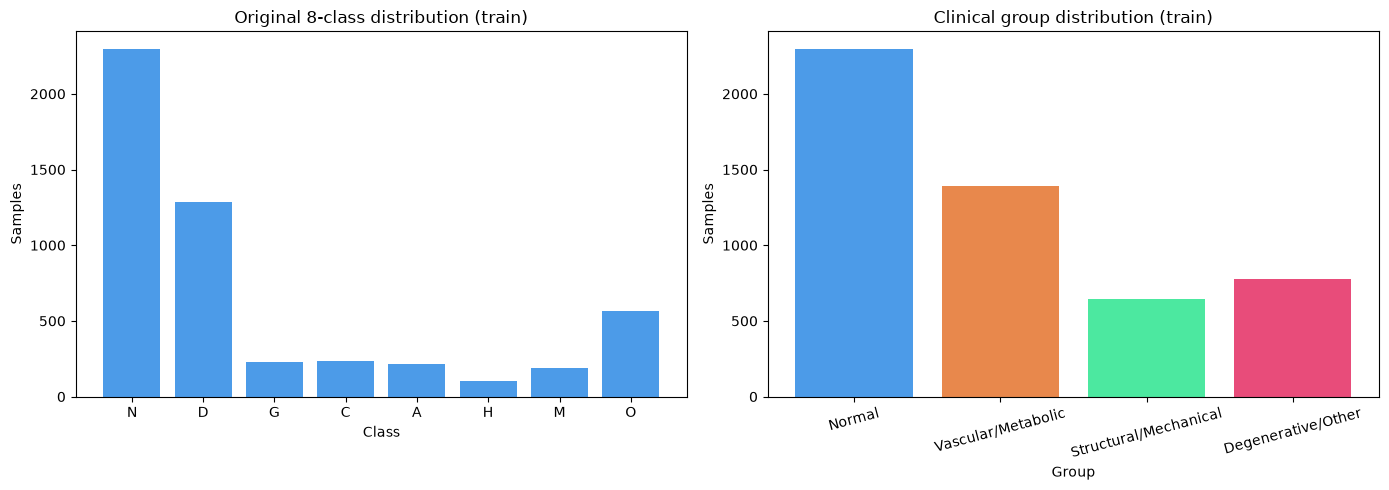

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orig_counts = y_train.value_counts().sort_index()
orig_labels = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
axes[0].bar(orig_labels, orig_counts, color='#4C9BE8')
axes[0].set_title('Original 8-class distribution (train)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Samples')

group_counts = y_train_grouped.value_counts().sort_index()
axes[1].bar(GROUP_NAMES, group_counts, color=['#4C9BE8', '#E8884C', '#4CE8A0', '#E84C7A'])
axes[1].set_title('Clinical group distribution (train)')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Samples')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../figures/group_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.3 Load Images

Images resized to **224×224** (EfficientNetB0 native resolution). Passed as `float32 [0–255]`
without manual normalisation — EfficientNetB0 includes a built-in rescaling layer.

In [ ]:
if 'IMAGE_FOLDER_PATH' not in vars():
    IMAGE_FOLDER_PATH = '../preprocessed_images'
IMAGE_SIZE = (224, 224)

X_train_images = load_images(X_train['filename'], IMAGE_FOLDER_PATH)
print(f'Loaded {X_train_images.shape[0]} training images at {IMAGE_SIZE}')

# 3. Model Architecture

**EfficientNetB0** (ImageNet pre-trained, frozen) with a **4-class** classification head:

```
GlobalAveragePooling2D → Dense(256, ReLU, L2=0.01) → Dropout(0.5) → Dense(4, softmax)
```

In [8]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu",
                               kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs), base_model

model, base_model = build_transfer_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
y_train_grouped = y_train_grouped.reset_index(drop=True)
print(y_train_grouped.head())


0    1
1    0
2    0
3    1
4    0
Name: target, dtype: int64


# 4. Validation Split

Stratified 20% per group extracted from **original** images **before** augmentation.
`np.random.seed(511)` ensures reproducibility across runs.

In [10]:
np.random.seed(511)
validation_indices = []
for grp in sorted(y_train_grouped.unique()):
    grp_indices = y_train_grouped[y_train_grouped == grp].index
    n_val = max(1, int(len(grp_indices) * 0.2))
    chosen = np.random.choice(grp_indices, n_val, replace=False)
    validation_indices.extend(chosen)

validation_indices = np.array(validation_indices)

X_val          = X_train_images[validation_indices]
y_val          = y_train_grouped[validation_indices]

X_train_images = np.delete(X_train_images, validation_indices, axis=0)
y_train_grouped = y_train_grouped.drop(validation_indices).reset_index(drop=True)

print(f"Validation set: {X_val.shape[0]}  |  Training set: {X_train_images.shape[0]}")
print("Groups in validation:", dict(pd.Series(y_val.values).value_counts().sort_index()))


Validation set: 1020  |  Training set: 4093
Groups in validation: {0: np.int64(459), 1: np.int64(277), 2: np.int64(129), 3: np.int64(155)}


# 5. Data Augmentation

Tiered strategy targeting ~1.2:1 imbalance ratio after augmentation.

| Group | Original | Copies | Total |
|---|---|---|---|
| Normal (0) | ~1839 | 0 | ~1839 |
| Vascular (1) | ~1111 | 1 | ~2222 |
| Structural (2) | ~518 | 3 | ~2072 |
| Degenerative (3) | ~623 | 2 | ~1869 |

**Resulting imbalance ratio: ~1.2:1** (down from 3.55:1).

In [ ]:
# Copies per group — tiered to achieve ~1.2:1 imbalance ratio after augmentation
COPIES_PER_CLASS = {0: 0, 1: 1, 2: 3, 3: 2}

In [ ]:
X_train_augmented, y_train_augmented = augment_images(X_train_images, y_train_grouped, COPIES_PER_CLASS)
print(f"Augmented: {X_train_augmented.shape[0]}  |  Training originals: {X_train_images.shape[0]}")

## 5.1 Augmented Sample Images

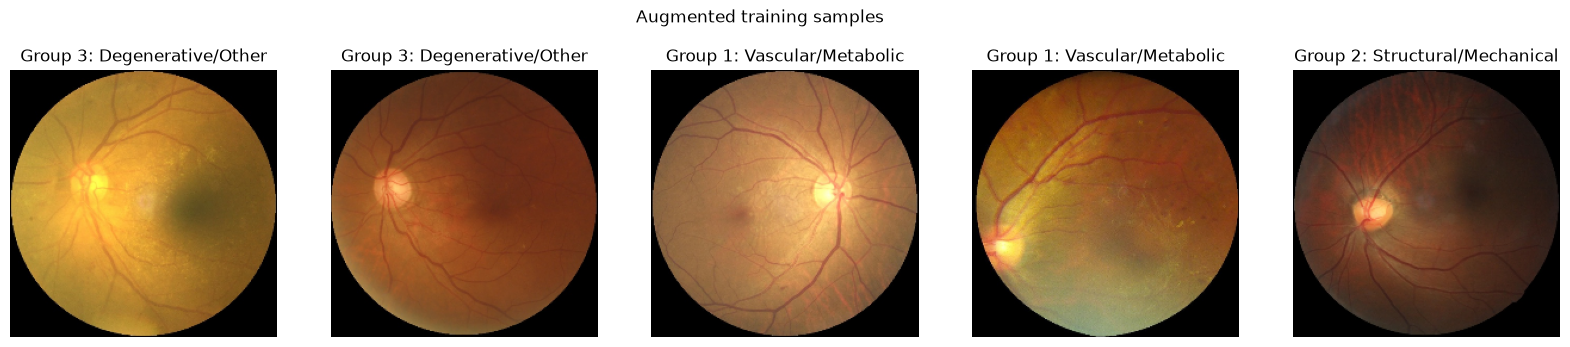

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    idx = np.random.randint(0, len(X_train_augmented))
    axes[i].imshow(X_train_augmented[idx].astype(np.uint8))
    axes[i].set_title(f"Group {y_train_augmented[idx]}: {GROUP_NAMES[y_train_augmented[idx]]}")
    axes[i].axis("off")
plt.suptitle("Augmented training samples")
plt.show()


## 5.2 Combined Class Distribution

In [14]:
print("Original training set:")
print(y_train_grouped.value_counts().sort_index())

unique, counts = np.unique(y_train_augmented, return_counts=True)
print("\nAugmented additions:")
for u, c in zip(unique, counts):
    print(f"  Group {u} ({GROUP_NAMES[u]}): +{c}")


Original training set:
target
0    1839
1    1112
2     518
3     624
Name: count, dtype: int64

Augmented additions:
  Group 1 (Vascular/Metabolic): +1112
  Group 2 (Structural/Mechanical): +1554
  Group 3 (Degenerative/Other): +1248


## 5.3 Combine Original and Augmented

In [15]:
X_train_combined = np.concatenate((X_train_images, X_train_augmented), axis=0)
y_train_combined = np.concatenate((y_train_grouped, y_train_augmented), axis=0)
print(f"Total training samples: {X_train_combined.shape[0]}")
print("Final distribution:")
for g, name in enumerate(GROUP_NAMES):
    n = (y_train_combined == g).sum()
    print(f"  {g} {name}: {n}")
min_count = min((y_train_combined == g).sum() for g in range(4))
max_count = max((y_train_combined == g).sum() for g in range(4))
print(f"Imbalance ratio: {max_count / min_count:.2f}:1")


Total training samples: 8007
Final distribution:
  0 Normal: 1839
  1 Vascular/Metabolic: 2224
  2 Structural/Mechanical: 2072
  3 Degenerative/Other: 1872
Imbalance ratio: 1.21:1


# 6. Training — Phase 4 (Frozen Base)

Train only the classification head. Balanced class weights compensate for residual imbalance.
`ReduceLROnPlateau` halves lr after 5 stagnant epochs; `EarlyStopping` (patience=25)
restores the best checkpoint.

In [16]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_combined),
    y=y_train_combined
)
class_weights_dict = dict(enumerate(class_weights_array))
print("Class weights:", {k: round(v, 3) for k, v in class_weights_dict.items()})

early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_combined, y_train_combined,
    epochs=120,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)


Class weights: {0: np.float64(1.088), 1: np.float64(0.9), 2: np.float64(0.966), 3: np.float64(1.069)}
Epoch 1/120
251/251 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.4636 - loss: 2.0921 - val_accuracy: 0.4059 - val_loss: 1.3673 - learning_rate: 0.0010
Epoch 2/120
251/251 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.4978 - loss: 1.2508 - val_accuracy: 0.5010 - val_loss: 1.2381 - learning_rate: 0.0010
Epoch 3/120
251/251 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.5079 - loss: 1.1857 - val_accuracy: 0.5000 - val_loss: 1.1961 - learning_rate: 0.0010
Epoch 4/120
251/251 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.5124 - loss: 1.1621 - val_accuracy: 0.5363 - val_loss: 1.1136 - learning_rate: 0.0010
Epoch 5/120
251/251 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.5028 - loss: 1.1666 - val_accuracy: 0.4539 - val_loss: 1.2053 - learning_rate: 0.0010
Epoch 6/120
251/251 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.5079 - loss: 1.1537 - val_accuracy: 0.5216 - val_loss: 1.171

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Phase 4 — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Phase 4 — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}  |  Epochs run: {len(history.history['loss'])}")

In [17]:
model.save('../models/efficientnetb0_grouped_phase4.h5')
print('Phase 4 model saved -> models/efficientnetb0_grouped_phase4.h5')


Phase 4 model saved -> models/efficientnetb0_grouped_phase4.h5


# 7. Evaluation — Phase 4

In [ ]:
X_test_images = load_images(X_test['filename'], IMAGE_FOLDER_PATH)
print(f'Loaded {X_test_images.shape[0]} test images')

## 7.1 Confusion Matrix

40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step


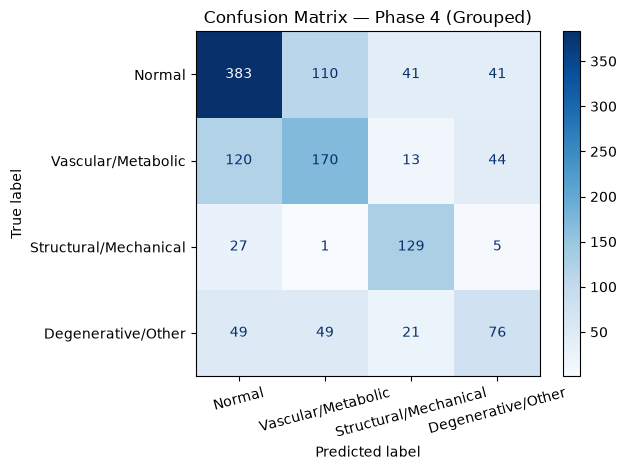

In [19]:
y_pred = model.predict(X_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_grouped, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUP_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Phase 4 (Grouped)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7.2 Loss & Accuracy

In [20]:
accuracy = accuracy_score(y_test_grouped, y_pred_classes)
loss = log_loss(y_test_grouped, y_pred)
print(f"Loss:     {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Loss:     0.9472
Accuracy: 0.5927


## 7.3 Per-Class Report

In [21]:
print(classification_report(y_test_grouped, y_pred_classes, target_names=GROUP_NAMES))


                       precision    recall  f1-score   support

               Normal       0.66      0.67      0.66       575
   Vascular/Metabolic       0.52      0.49      0.50       347
Structural/Mechanical       0.63      0.80      0.70       162
   Degenerative/Other       0.46      0.39      0.42       195

             accuracy                           0.59      1279
            macro avg       0.57      0.59      0.57      1279
         weighted avg       0.59      0.59      0.59      1279



# 8. Training — Phase 5 (Fine-tuning)

Unfreeze the **last 20 layers** of EfficientNetB0 and fine-tune at lr=1e-5 to adapt
pre-trained features to the retinal domain.

> **Requires GPU.** In Google Colab: *Runtime → Change runtime type → T4 GPU*.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ft.history['loss'], label='Train')
axes[0].plot(history_ft.history['val_loss'], label='Validation')
axes[0].set_title('Phase 5 — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_ft.history['accuracy'], label='Train')
axes[1].plot(history_ft.history['val_accuracy'], label='Validation')
axes[1].set_title('Phase 5 — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Best val accuracy: {max(history_ft.history['val_accuracy']):.4f}  |  Epochs run: {len(history_ft.history['loss'])}")

In [22]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}/{len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tuning_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
fine_tuning_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-8, verbose=1)

history_ft = model.fit(
    X_train_combined, y_train_combined,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=16,
    callbacks=[fine_tuning_stopping, fine_tuning_lr],
    class_weight=class_weights_dict
)


Trainable layers: 20/238
Epoch 1/100
501/501 ━━━━━━━━━━━━━━━━━━━━ 528s 952ms/step - accuracy: 0.5571 - loss: 1.0836 - val_accuracy: 0.5676 - val_loss: 1.0681 - learning_rate: 1.0000e-05
Epoch 2/100
501/501 ━━━━━━━━━━━━━━━━━━━━ 441s 881ms/step - accuracy: 0.5866 - loss: 1.0197 - val_accuracy: 0.5686 - val_loss: 1.0485 - learning_rate: 1.0000e-05
Epoch 3/100
501/501 ━━━━━━━━━━━━━━━━━━━━ 423s 844ms/step - accuracy: 0.6120 - loss: 0.9798 - val_accuracy: 0.5882 - val_loss: 1.0382 - learning_rate: 1.0000e-05
Epoch 4/100
501/501 ━━━━━━━━━━━━━━━━━━━━ 404s 804ms/step - accuracy: 0.6192 - loss: 0.9601 - val_accuracy: 0.5892 - val_loss: 1.0195 - learning_rate: 1.0000e-05
Epoch 5/100
501/501 ━━━━━━━━━━━━━━━━━━━━ 413s 824ms/step - accuracy: 0.6296 - loss: 0.9345 - val_accuracy: 0.6078 - val_loss: 1.0123 - learning_rate: 1.0000e-05
Epoch 6/100
501/501 ━━━━━━━━━━━━━━━━━━━━ 451s 900ms/step - accuracy: 0.6411 - loss: 0.9221 - val_accuracy: 0.6069 - val_loss: 1.0023 - learning_rate: 1.0000e-05
Epoch 7/1

## 8.1 Evaluation — Phase 5

40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 951ms/step


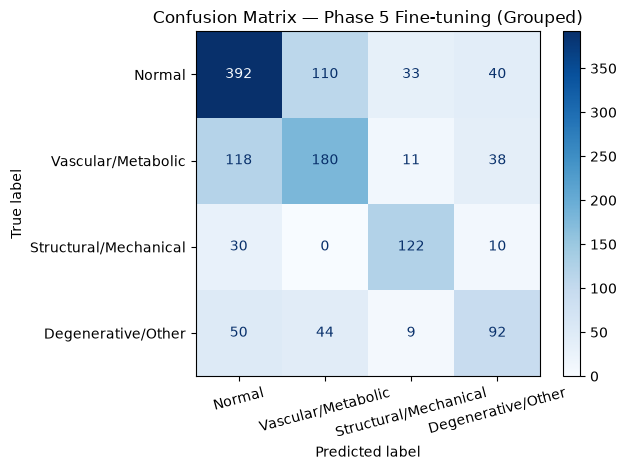

Loss:     0.9088
Accuracy: 0.6145

                       precision    recall  f1-score   support

               Normal       0.66      0.68      0.67       575
   Vascular/Metabolic       0.54      0.52      0.53       347
Structural/Mechanical       0.70      0.75      0.72       162
   Degenerative/Other       0.51      0.47      0.49       195

             accuracy                           0.61      1279
            macro avg       0.60      0.61      0.60      1279
         weighted avg       0.61      0.61      0.61      1279



In [23]:
y_pred_ft = model.predict(X_test_images)
y_pred_ft_classes = np.argmax(y_pred_ft, axis=1)

cm_ft = confusion_matrix(y_test_grouped, y_pred_ft_classes)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=GROUP_NAMES)
disp_ft.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Phase 5 Fine-tuning (Grouped)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

accuracy_ft = accuracy_score(y_test_grouped, y_pred_ft_classes)
loss_ft = log_loss(y_test_grouped, y_pred_ft)
print(f"Loss:     {loss_ft:.4f}")
print(f"Accuracy: {accuracy_ft:.4f}")

print()
print(classification_report(y_test_grouped, y_pred_ft_classes, target_names=GROUP_NAMES))


In [24]:
model.save('../models/efficientnetb0_grouped_finetuned.keras')
print('Fine-tuned model saved -> models/efficientnetb0_grouped_finetuned.keras')


Fine-tuned model saved -> models/efficientnetb0_grouped_finetuned.keras
